In [1]:
# Standard library imports
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

# Scientific computing
import numpy as np
import pandas as pd

# Deep learning and probabilistic programming
import torch
import torch.nn as nn
import pyro

# Single-cell analysis
import scanpy as sc
import scvelo as scv
import cellrank as cr

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# LSD model imports
from codes.lsd_train import LSD
from codes.config import LSDConfig
from codes.utils import plot_random_walks

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create output directories
FIGURE_DIR = Path("../Figures/Zebrafish")
FIGURE_SVG_DIR = Path("../Figures/Zebrafish_SVG")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_SVG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figure directories created: {FIGURE_DIR}, {FIGURE_SVG_DIR}")

Using device: cuda
Figure directories created: ../Figures/Zebrafish, ../Figures/Zebrafish_SVG


In [2]:
# Load training data
DATA_PATH = "/home/saberi/projects/lsd/data/Zebrafish/perturb_train_adata.h5ad"
adata = sc.read(DATA_PATH)

print(f"Loaded data shape: {adata.shape}")
print(f"Number of cells: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")
print(f"\nAvailable annotations:")
print(f"  obs keys: {list(adata.obs.keys())}")
print(f"  var keys: {list(adata.var.keys())}")
print(f"  obsm keys: {list(adata.obsm.keys())}")
print(f"  layers: {list(adata.layers.keys())}")

# Display cluster distribution
print("\nCluster distribution:")
print(adata.obs['clusters'].value_counts())

Loaded data shape: (2068, 2000)
Number of cells: 2,068
Number of genes: 2,000

Available annotations:
  obs keys: ['Stage', 'gt_terminal_states', 'lineages', 'prior_pseudotime', 'librarysize', 'n_counts', 'clusters', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes']
  var keys: ['ct_gene_corr', 'ct_correlates']
  obsm keys: ['T_fwd_force_directed', 'X_force_directed', 'X_pca']
  layers: ['Ms', 'Mu', 'raw', 'spliced', 'unspliced']

Cluster distribution:
clusters
Notochord            977
Prechordal Plate     716
Early Blastomeres    375
Name: count, dtype: int64


In [3]:
# Configure optimization hyperparameters based on best grid search results
cfg = LSDConfig()
cfg.model.layer_dims.potential = [16, 16]
cfg.optimizer.adam.lr = 2e-3
cfg.optimizer.adam.T_0 = 60
cfg.walks.batch_size = 256
cfg.walks.path_len = 40
cfg.walks.num_walks = 2048
cfg.walks.random_state = 42

# Set random seed for reproducibility
pyro.set_rng_seed(42)

# Initialize LSD model
lsd = LSD(
    adata,
    cfg,
    device=device,                 # GPU device
    lib_size_key="librarysize",   # Key for library size in adata.obs
    raw_count_key="raw",           # Key for raw counts in adata.layers
)
lsd.set_prior_transition(prior_transition=adata.obsp["prior_transition"])
lsd.prepare_walks()

[LSD] Prior transition matrix set from user input.


Training model...
Model will be saved to: ../../Models/Zebrafish_model


Training Epochs: 100%|██████████| 30/30 [01:07<00:00,  2.25s/it, -ELBO=0.5689, Potential Metric=0.1223, Entropy Metric=0.0112]


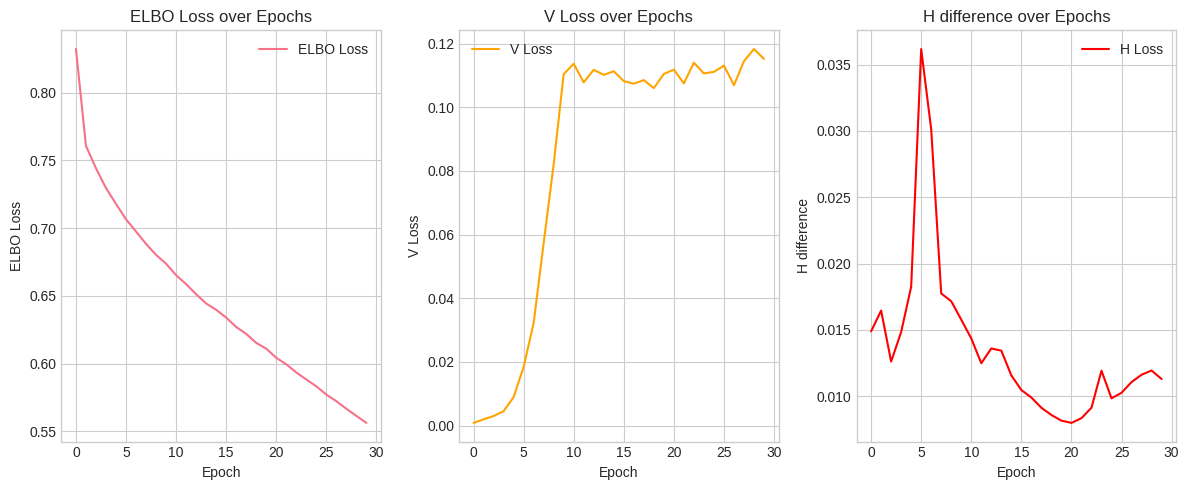


Training completed! Model saved to ../../Models/Zebrafish_model


In [4]:
# Clear parameter store to ensure clean training
pyro.clear_param_store()

# Define model directory
MODEL_DIR = "../../Models/Zebrafish_model"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Training model...")
print(f"Model will be saved to: {MODEL_DIR}")

# Train the model
# Note: Set num_epochs to smaller value (e.g., 50) for testing
lsd.train(
    num_epochs=30,           # Number of training epochs
    save_dir=MODEL_DIR,       # Directory to save checkpoints
    save_interval=15          # Save checkpoint every 50 epochs
)

print(f"\nTraining completed! Model saved to {MODEL_DIR}")